In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [3]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# Data loaders

In [ ]:
batch_size_train = 64
batch_size_test = 1000
root_dir = "../data"


train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        root_dir,
        train=True,
        download=False,
        transform=transforms.Compose(
            [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
        ),
    ),
    batch_size=batch_size_train,
    shuffle=True,
)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        root_dir,
        train=False,
        download=False,
        transform=transforms.Compose(
            [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
        ),
    ),
    batch_size=batch_size_test,
    shuffle=True,
)

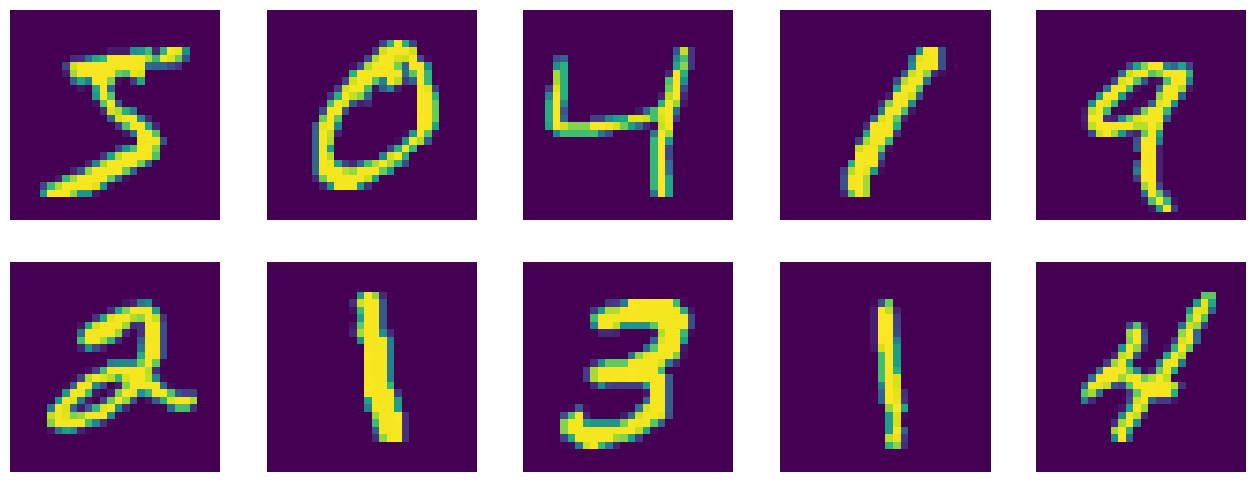

In [ ]:
# The MNIST dataset is the handwritten dataset.
plt.figure(figsize=(16, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    image, _ = train_loader.dataset[i]
    plt.imshow(image.squeeze().numpy())
    plt.axis("off")

# Define CNN and MLP models

In [ ]:
class CNN(nn.Module):
    def __init__(self, input_size, n_feature, output_size):
        super(CNN, self).__init__()
        self.n_feature = n_feature

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=n_feature, kernel_size=5)

        self.conv2 = nn.Conv2d(n_feature, n_feature, kernel_size=5)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(n_feature * 4 * 4, 50)

        self.fc2 = nn.Linear(
            50, output_size
        )  # input features: 50, 0utput number of classes (e.g., 10 for MNIST)

    def forward(self, x, verbose=False):

        x = self.conv1(x)
        x = F.relu(x)

        x = F.max_pool2d(x, kernel_size=2)

        x = self.conv2(x)
        x = F.relu(x)

        x = F.max_pool2d(x, kernel_size=2)

        x = self.flatten(x)

        x = self.fc1(x)
        x = F.relu(x)

        x = self.fc2(x)

        x = F.log_softmax(x, dim=1)
        return x


class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 50)
        self.fc3 = nn.Linear(50, output_size)

    def forward(self, x):
        x = x.view(-1, 28 * 28)

        x = F.relu(self.fc1(x))

        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        x = F.log_softmax(x, dim=1)
        return x

# Training and evaluation functions

In [ ]:
def train(model, device, train_loader, optimizer):
    model.train()
    train_loss = 0
    correct = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * data.size(0)  # accumulate loss
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()

    train_loss /= len(train_loader.dataset)
    accuracy = 100.0 * correct / len(train_loader.dataset)
    return train_loss, accuracy


def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction="sum").item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100.0 * correct / len(test_loader.dataset)
    return test_loss, accuracy

# Instantiate models and optimizers

In [ ]:
input_size = 28 * 28
output_size = 10
n_feature = 6  # CNN feature maps
hidden_size = 100  # MLP hidden neurons

model_cnn = CNN(input_size, n_feature, output_size).to(device)
model_mlp = MLP(input_size, hidden_size, output_size).to(device)

optimizer_cnn = optim.SGD(model_cnn.parameters(), lr=0.01, momentum=0.5)
optimizer_mlp = optim.SGD(model_mlp.parameters(), lr=0.01, momentum=0.5)

# Train and test both models

In [ ]:
import matplotlib.pyplot as plt

num_epochs = 5

# Initialize lists to store metrics
cnn_train_losses, cnn_train_accs = [], []
cnn_test_losses, cnn_test_accs = [], []

mlp_train_losses, mlp_train_accs = [], []
mlp_test_losses, mlp_test_accs = [], []

print("Training CNN...")
for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train(model_cnn, device, train_loader, optimizer_cnn)
    test_loss, test_acc = test(model_cnn, device, test_loader)
    cnn_train_losses.append(train_loss)
    cnn_train_accs.append(train_acc)
    cnn_test_losses.append(test_loss)
    cnn_test_accs.append(test_acc)
    print(
        f"Epoch {epoch} CNN - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%"
    )

print("Training MLP...")
for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train(model_mlp, device, train_loader, optimizer_mlp)
    test_loss, test_acc = test(model_mlp, device, test_loader)
    mlp_train_losses.append(train_loss)
    mlp_train_accs.append(train_acc)
    mlp_test_losses.append(test_loss)
    mlp_test_accs.append(test_acc)
    print(
        f"Epoch {epoch} MLP - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%"
    )

Training CNN...
Epoch 1 CNN - Train Loss: 0.6732, Train Acc: 78.21%, Test Loss: 0.1598, Test Acc: 95.22%
Epoch 2 CNN - Train Loss: 0.1379, Train Acc: 95.74%, Test Loss: 0.0993, Test Acc: 96.86%
Epoch 3 CNN - Train Loss: 0.1036, Train Acc: 96.78%, Test Loss: 0.0854, Test Acc: 97.14%
Epoch 4 CNN - Train Loss: 0.0891, Train Acc: 97.25%, Test Loss: 0.0724, Test Acc: 97.54%
Epoch 5 CNN - Train Loss: 0.0785, Train Acc: 97.58%, Test Loss: 0.0712, Test Acc: 97.76%
Training MLP...
Epoch 1 MLP - Train Loss: 0.6152, Train Acc: 82.47%, Test Loss: 0.2774, Test Acc: 91.82%
Epoch 2 MLP - Train Loss: 0.2454, Train Acc: 92.91%, Test Loss: 0.2007, Test Acc: 94.15%
Epoch 3 MLP - Train Loss: 0.1889, Train Acc: 94.53%, Test Loss: 0.1636, Test Acc: 95.05%
Epoch 4 MLP - Train Loss: 0.1536, Train Acc: 95.57%, Test Loss: 0.1465, Test Acc: 95.62%
Epoch 5 MLP - Train Loss: 0.1294, Train Acc: 96.29%, Test Loss: 0.1231, Test Acc: 96.39%


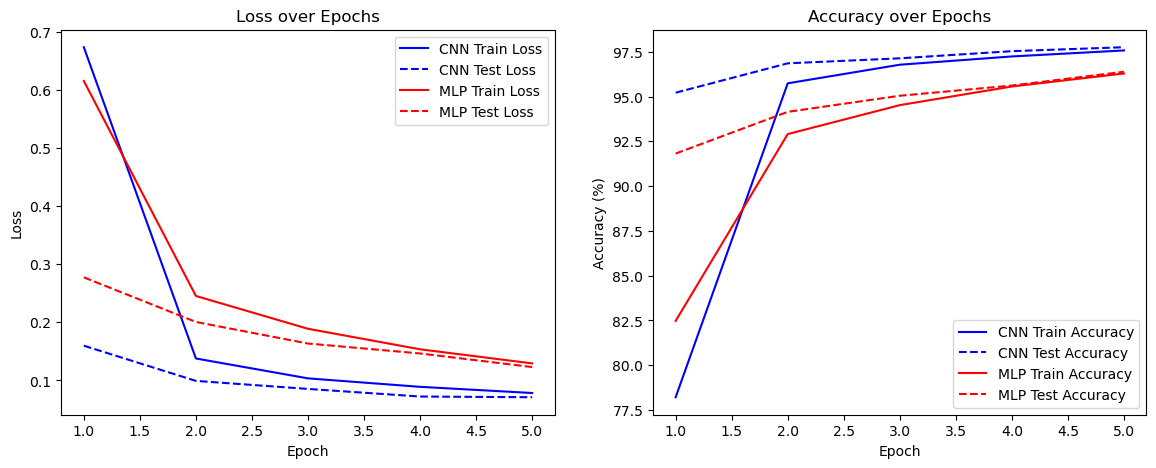

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, cnn_train_losses, "b-", label="CNN Train Loss")
plt.plot(epochs, cnn_test_losses, "b--", label="CNN Test Loss")
plt.plot(epochs, mlp_train_losses, "r-", label="MLP Train Loss")
plt.plot(epochs, mlp_test_losses, "r--", label="MLP Test Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, cnn_train_accs, "b-", label="CNN Train Accuracy")
plt.plot(epochs, cnn_test_accs, "b--", label="CNN Test Accuracy")
plt.plot(epochs, mlp_train_accs, "r-", label="MLP Train Accuracy")
plt.plot(epochs, mlp_test_accs, "r--", label="MLP Test Accuracy")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.show()